# Task 1: Sparse Networks from Scratch

In the first task, students will train sparse networks with a fixed random connectivity mask. The mask M
is generated at initialization and remains unchanged throughout training. Students should compare at least
two optimization methods: SGD with momentum and Adam. The goal is to investigate how different
optimizers behave when training highly sparse networks. Suggested questions include:
- How does sparsity a!ect convergence speed?
- How does accuracy degrade as sparsity increases?
- Do different optimizers behave di!erently under high sparsity?

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load libraries

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# quarto preview 01_task_1.ipynb --to pdf

In [2]:
# model_path = "/content/drive/MyDrive/Posgrados/2025/Duke/ECE 685D/Final project"
# sys.path.append(model_path)

model_path = "."

from models import ResNetCIFAR

In [3]:
use_pin_memory = torch.cuda.is_available()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_workers = min(2, os.cpu_count())

## Load data

In [4]:
# Standard CIFAR-10 transforms
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=f"{model_path}/data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

testset = torchvision.datasets.CIFAR10(
    root=f"{model_path}/data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

## Configuration

In [5]:
sparsities = [0.90, 0.95, 0.98]
optimizers = ["sgd", "adam"]

## Main Experiment

In [ ]:
epochs = 15
criterion = nn.CrossEntropyLoss()

In [7]:
output_dir = "/content/drive/MyDrive/Posgrados/2025/Duke/ECE 685D/Final project/results"

### Helper Functions

In [8]:
def get_static_masks(model, sparsity):
    """Generates the fixed binary mask M"""
    masks = {}
    for name, param in model.named_parameters():
        if "conv" in name or "linear" in name:
            mask = torch.rand(param.size()).to(device)
            mask = (mask > sparsity).float()
            masks[name] = mask
        else:
            masks[name] = torch.ones(param.size()).to(device)
    return masks


@torch.no_grad()
def apply_masks(model, masks):
    """Applies W = M * theta"""
    for name, param in model.named_parameters():
        param.mul_(masks[name])

### Actual experiment

 This section runs the full experimental loop over sparsity levels and optimizers. For each configuration, a model is initialized, a fixed random mask is applied, and training proceeds while enforcing the same sparse connectivity throughout. Performance metrics are tracked at every epoch and saved for later analysis.

In [ ]:
for s in sparsities:
    for opt_name in optimizers:
        print(f"\nStarting Experiment: Sparsity={s*100}%, Optimizer={opt_name}")

        # Initialize
        model = ResNetCIFAR().to(device)
        masks = get_static_masks(model, s)
        apply_masks(model, masks)

        if opt_name == "sgd":
            optimizer = optim.SGD(
                model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4
            )
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

        for epoch in range(epochs):
            # --- Training Phase ---
            model.train()
            train_loss, train_correct, train_total = 0.0, 0, 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                apply_masks(model, masks)  # Keep connectivity fixed

                train_loss += loss.item()
                _, predicted = outputs.max(1)
                train_total += labels.size(0)
                train_correct += predicted.eq(labels).sum().item()

            # --- Evaluation Phase ---
            model.eval()
            test_loss, test_correct, test_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in testloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    test_loss += loss.item()
                    _, predicted = outputs.max(1)
                    test_total += labels.size(0)
                    test_correct += predicted.eq(labels).sum().item()

            # Record Metrics
            history["train_loss"].append(train_loss / len(trainloader))
            history["train_acc"].append(100.0 * train_correct / train_total)
            history["test_loss"].append(test_loss / len(testloader))
            history["test_acc"].append(100.0 * test_correct / test_total)

            print(
                f"Epoch {epoch+1}: Train Loss {history['train_loss'][-1]:.4f} | Test Acc {history['test_acc'][-1]:.2f}%"
            )

        # --- Save Joblib ---
        experiment_results = {
            "sparsity": s,
            "optimizer": opt_name,
            "train_loss": history["train_loss"],
            "train_acc": history["train_acc"],
            "test_loss": history["test_loss"],
            "test_acc": history["test_acc"],
            "masks": masks,  # Required deliverable
            "model_state": model.state_dict(),  # For future analysis
        }

        filename = os.path.join(
            output_dir, f"task_1_{opt_name}_{int(s*100)}_sparsity.joblib"
        )
        joblib.dump(experiment_results, filename)
        print(f"Results saved to {filename}!")


Starting Experiment: Sparsity=90.0%, Optimizer=sgd
Epoch 1: Train Loss 1.4800 | Test Acc 46.15%
Epoch 2: Train Loss 1.0508 | Test Acc 57.55%
Epoch 3: Train Loss 0.8884 | Test Acc 54.54%
Epoch 4: Train Loss 0.8074 | Test Acc 51.62%
Epoch 5: Train Loss 0.7596 | Test Acc 69.40%
Epoch 6: Train Loss 0.7299 | Test Acc 64.62%
Epoch 7: Train Loss 0.7096 | Test Acc 67.02%
Epoch 8: Train Loss 0.6902 | Test Acc 68.87%
Epoch 9: Train Loss 0.6775 | Test Acc 70.44%
Epoch 10: Train Loss 0.6648 | Test Acc 69.63%
Epoch 11: Train Loss 0.6513 | Test Acc 70.86%
Epoch 12: Train Loss 0.6478 | Test Acc 60.67%
Epoch 13: Train Loss 0.6390 | Test Acc 70.60%
Epoch 14: Train Loss 0.6302 | Test Acc 71.90%
Epoch 15: Train Loss 0.6326 | Test Acc 70.14%
Results saved to /content/drive/MyDrive/Posgrados/2025/Duke/ECE 685D/Final project/results/task_1_sgd_90_sparsity.joblib!

Starting Experiment: Sparsity=90.0%, Optimizer=adam
Epoch 1: Train Loss 1.5871 | Test Acc 48.50%
Epoch 2: Train Loss 1.1645 | Test Acc 58.19%
Ep

 The printed outputs provide a quick view of training loss and test accuracy across epochs for each configuration. As sparsity increases, performance generally degrades, reflecting the reduced capacity of the network. Differences between optimizers also become more pronounced at higher sparsities, with Adam often converging more smoothly than SGD.

These logs only show a subset of the recorded metrics. Additional information such as training accuracy, test loss, and the full training history are stored in the saved joblib files for more detailed analysis.

## Evaluation

### Functions

In [6]:
def plot_training_and_validation(results):
    sns.set_theme(style="whitegrid", context="talk", palette="deep")

    sparsities = [0.90, 0.95, 0.98]
    opts = ["sgd", "adam"]

    for s in sparsities:
        rows = []

        # --- Reshape data into tidy format ---
        for opt in opts:
            if s in results[opt]:
                n_epochs = len(results[opt][s]["train_loss"])
                for epoch in range(n_epochs):
                    rows.append(
                        {
                            "epoch": epoch,
                            "optimizer": opt.upper(),
                            "split": "Train",
                            "loss": results[opt][s]["train_loss"][epoch],
                            "accuracy": results[opt][s]["train_acc"][epoch],
                        }
                    )
                    rows.append(
                        {
                            "epoch": epoch,
                            "optimizer": opt.upper(),
                            "split": "Test",
                            "loss": results[opt][s]["test_loss"][epoch],
                            "accuracy": results[opt][s]["test_acc"][epoch],
                        }
                    )

        df = pd.DataFrame(rows)

        # --- Create figure ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(
            f"Optimization Analysis at {int(s*100)}% Sparsity",
            fontsize=18,
            weight="bold",
        )

        # --- Loss plot ---
        sns.lineplot(
            data=df,
            x="epoch",
            y="loss",
            hue="optimizer",
            style="split",
            markers=False,
            dashes={"Train": "", "Test": (4, 2)},
            ax=axes[0],
        )
        axes[0].set_title("Cross-Entropy Loss", fontsize=14)
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")

        # --- Accuracy plot ---
        sns.lineplot(
            data=df,
            x="epoch",
            y="accuracy",
            hue="optimizer",
            style="split",
            markers=False,
            dashes={"Train": "", "Test": (4, 2)},
            ax=axes[1],
        )
        axes[1].set_title("Accuracy (%)", fontsize=14)
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy (%)")

        # --- Final polish ---
        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend(title="")

        plt.savefig(f"img/sparsity_{int(s*100)}.png", dpi=300, bbox_inches="tight")
        plt.tight_layout()
        plt.show()

### Read results

In [7]:
output_dir = "results"

In [8]:
# Patch torch.load to force CPU
_original_torch_load = torch.load


def cpu_torch_load(*args, **kwargs):
    kwargs["map_location"] = torch.device("cpu")
    return _original_torch_load(*args, **kwargs)


torch.load = cpu_torch_load

results = {}

In [9]:
for opt_name in optimizers:
    results[opt_name] = {}
    for s in sparsities:
        file_path = os.path.join(
            output_dir, f"task_1_{opt_name}_{int(s*100)}_sparsity.joblib"
        )

        if os.path.exists(file_path):
            data = joblib.load(file_path)
            results[opt_name][s] = data
            print(f"Loaded: {file_path}")
        else:
            print(f"Missing: {file_path}")

Loaded: results/task_1_sgd_90_sparsity.joblib
Loaded: results/task_1_sgd_95_sparsity.joblib
Loaded: results/task_1_sgd_98_sparsity.joblib
Loaded: results/task_1_adam_90_sparsity.joblib
Loaded: results/task_1_adam_95_sparsity.joblib
Loaded: results/task_1_adam_98_sparsity.joblib


### Analysis

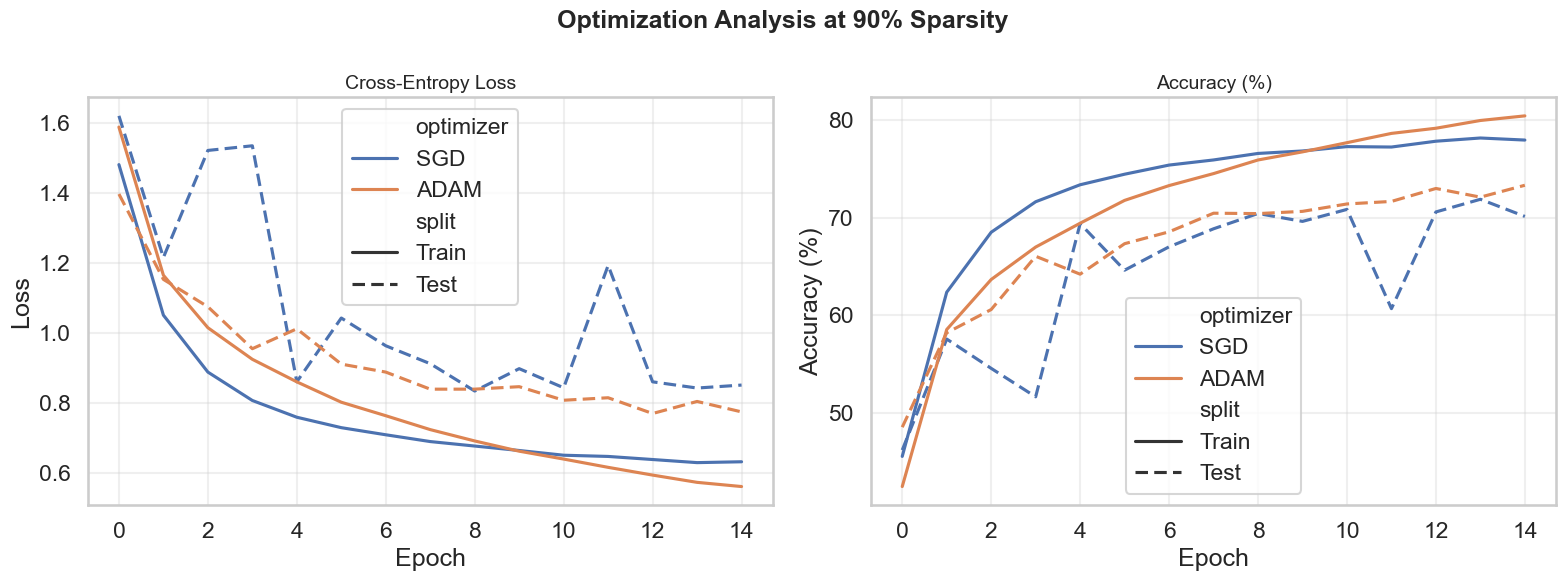

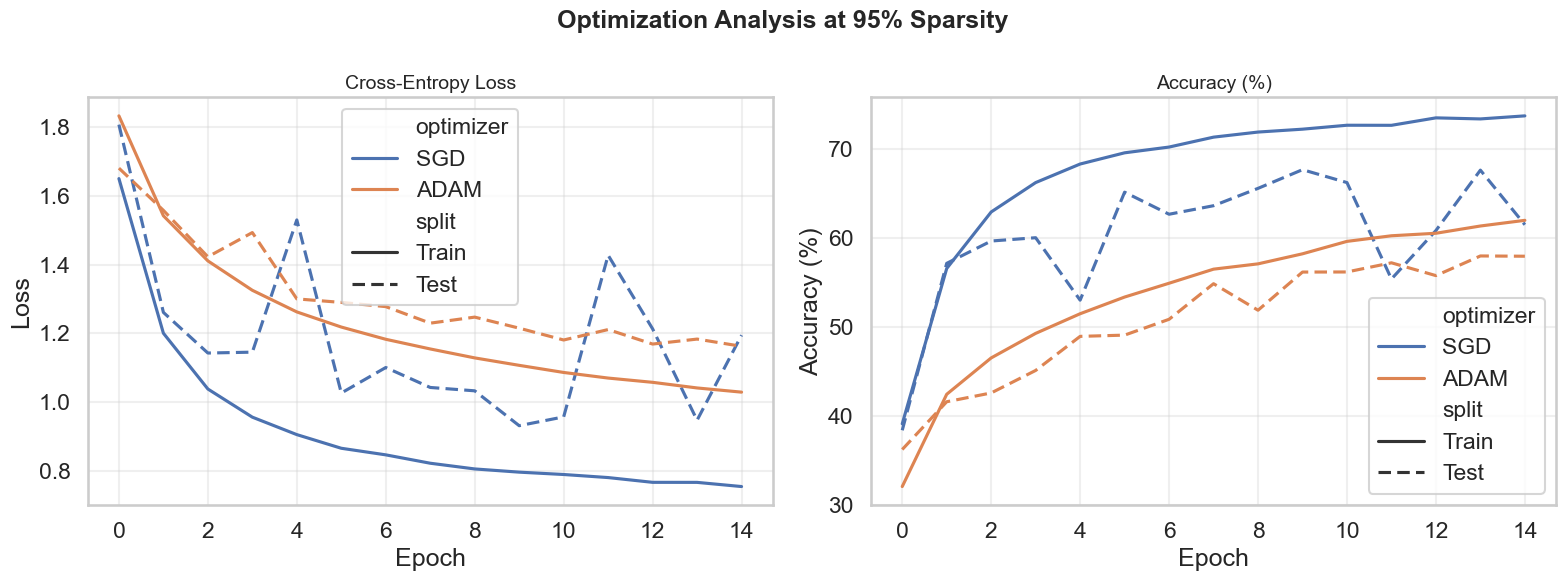

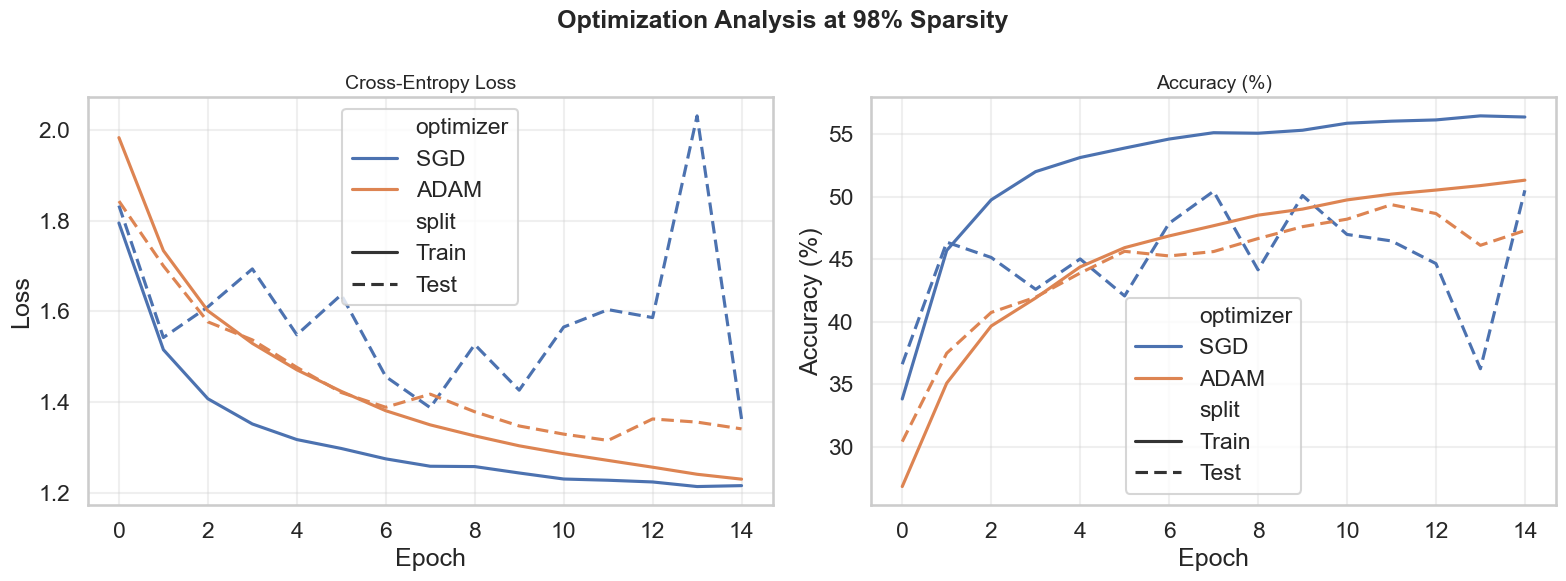

In [10]:
plot_training_and_validation(results)